# Practica: NLP - Metricas y Conclusiones

Alumno: Hannibal Tomasson Izquierdo

Como hemos demostrado en la etapa anterior, este problema de clasificacion binaria supervisada puede abordarse tanto a traves de tecnicas de Machine Learning, como Regresion Logistica y Random Forest, como de Deep Learning, usando en este caso arquitecturas incluyendo capas preentrenadas y BiLSTM.

Los modelos de ML son mas ligeros y requieren menos tiempo para ser entranados, y aun asi consiguen un rendimiento muy bueno en esta tarea.El modelo de DL requiere más recursos computacionales y tiempo de entrenamiento, pero tambien obtiene un rendimiento adecuado.


Al usar embeddings preentrenados, se logro una representacion semantica mas rica del texto sin entrenar embeddings desde cero. Aunque la Regresion Logistica obtuvo un rendimiento mejor en precision, el modelo LSTM demuestra buena capacidad de generalizacion, sin demasiado overfitting.

El significado de estos resultados es que ambos enfoques son validos, y que la eleccion entre uno u otro debe depender del contexto, la disponibilidad de datos, y las caracteristicas del problema a abordar.
Si nuestra prioridad es la velocidad y simplicidad, el modelo de Regresion Logistica es una opcion excelente. Si lo que buscamos es una mayor profundidad semantica y capacidad de adaptacion futura, el modelo con LSTM y embeddings GloVe puede ser una mejor opcion.

A continuacion generaremos informes de clasificacion asi como las curvas de aprendizaje del modelo DL, para poder compararlos y asi justificar nuesta eleccion de modelo.

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

# Cargamos los archivos de resultados

df_history = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/NLP/Practica/dl_training_history.csv')
y_true = np.load('/content/drive/MyDrive/Colab Notebooks/NLP/Practica/y_true_ml.npy')
y_pred_logreg = np.load('/content/drive/MyDrive/Colab Notebooks/NLP/Practica/y_pred_logreg.npy')
y_pred_rf = np.load('/content/drive/MyDrive/Colab Notebooks/NLP/Practica/y_pred_rf.npy')
y_pred_dl = np.load('/content/drive/MyDrive/Colab Notebooks/NLP/Practica/y_pred_dl.npy')

print("Archivos cargados.")

Archivos cargados.


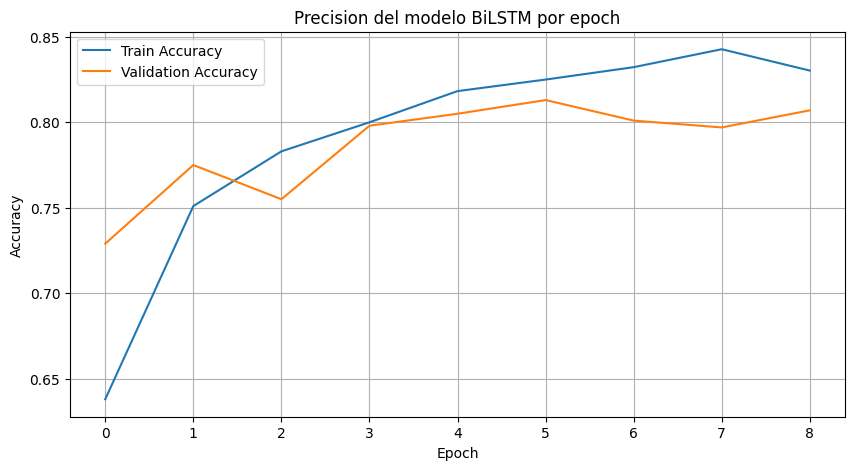

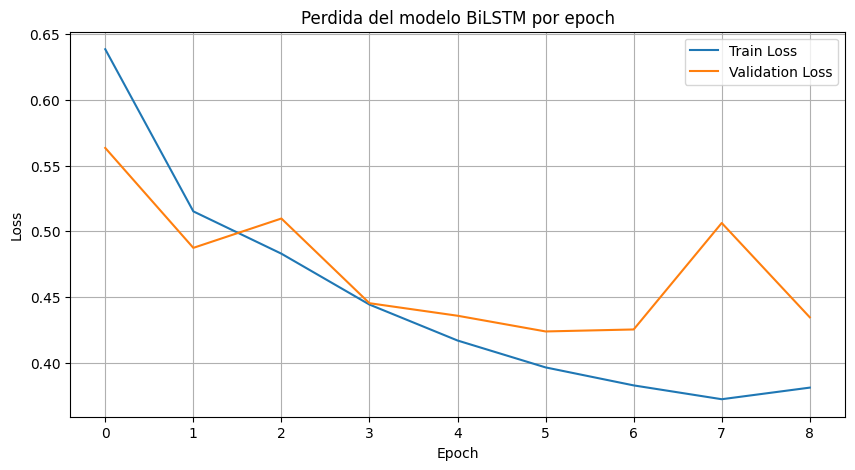

In [9]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(10, 5))
plt.plot(df_history['accuracy'], label='Train Accuracy')
plt.plot(df_history['val_accuracy'], label='Validation Accuracy')
plt.title('Precision del modelo BiLSTM por epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(10, 5))
plt.plot(df_history['loss'], label='Train Loss')
plt.plot(df_history['val_loss'], label='Validation Loss')
plt.title('Perdida del modelo BiLSTM por epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


Como vemos, la precision mejora de manera regular hasta llegar al epoch 7, donde observamos un aplanamiento, y posibilidad de overfitting, que se para gracias al Early Stopping.

In [10]:
print("Logistic Regression")
print(classification_report(y_true, y_pred_logreg, target_names=['neg', 'pos']))

print("\nRandom Forest")
print(classification_report(y_true, y_pred_rf, target_names=['neg', 'pos']))

print("\nBiLSTM + GloVe")
print(classification_report(y_true, y_pred_dl, target_names=['neg', 'pos']))

Logistic Regression
              precision    recall  f1-score   support

         neg       0.83      0.83      0.83       500
         pos       0.83      0.83      0.83       500

    accuracy                           0.83      1000
   macro avg       0.83      0.83      0.83      1000
weighted avg       0.83      0.83      0.83      1000


Random Forest
              precision    recall  f1-score   support

         neg       0.74      0.84      0.79       500
         pos       0.82      0.71      0.76       500

    accuracy                           0.78      1000
   macro avg       0.78      0.78      0.78      1000
weighted avg       0.78      0.78      0.78      1000


BiLSTM + GloVe
              precision    recall  f1-score   support

         neg       0.84      0.77      0.80       500
         pos       0.79      0.86      0.82       500

    accuracy                           0.81      1000
   macro avg       0.82      0.81      0.81      1000
weighted avg       0.82

Como podemos comprobar, los tres modelos tienen unas puntuacionesd de precision, recall y f1-score bastante similares. Destacan el modelo de Regresion Logistica y el de BiLSTM + GloVe, pero incluso el de Random Forest podria ser valido dependiendo de la situacion.


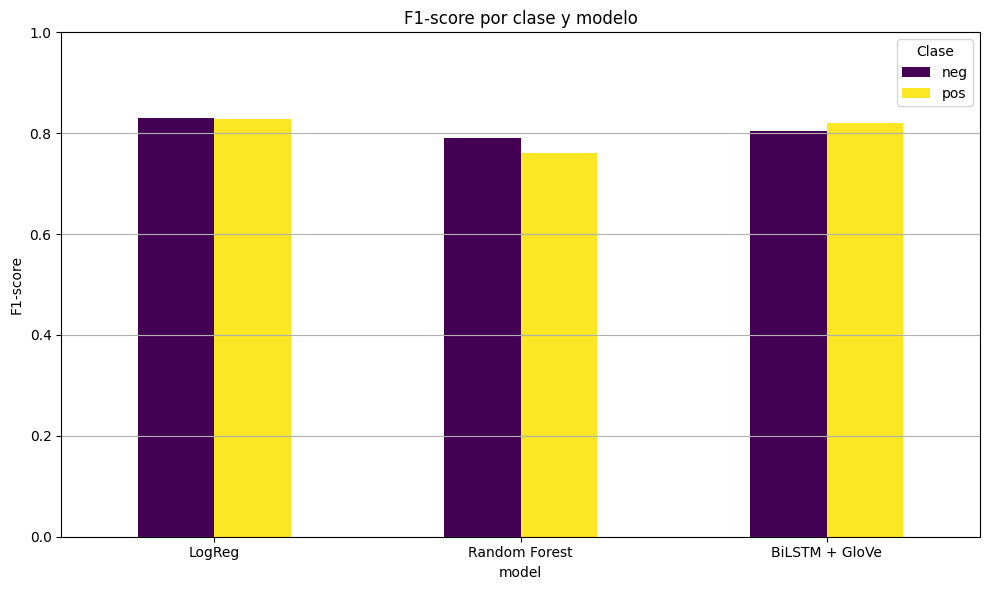

In [12]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Obtenemos el f1-score por clase de cada modelo
def get_f1_scores(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, target_names=['neg', 'pos'], output_dict=True)
    return {
        'model': model_name,
        'neg': report['neg']['f1-score'],
        'pos': report['pos']['f1-score']
    }

# Extraemos los valores
scores = [
    get_f1_scores(y_true, y_pred_logreg, 'LogReg'),
    get_f1_scores(y_true, y_pred_rf, 'Random Forest'),
    get_f1_scores(y_true, y_pred_dl, 'BiLSTM + GloVe')
]

# Convertimos a DataFrame
df_scores = pd.DataFrame(scores)

# Visualizamos el grafico
df_scores.set_index('model')[['neg', 'pos']].plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('F1-score por clase y modelo')
plt.ylabel('F1-score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(True, axis='y')
plt.legend(title='Clase')
plt.tight_layout()
plt.show()


Finalmente, la grafica nos muestra lo que ya habiamos identificado en pasos anteriores: Los tres modelos que hemos comparado tienen un rendimiento similar, con el modelo de Regresion Logistica quedando por delante de los otros dos tanto en precision como en recall y f1-score.

La diferencia no es demasiado grande, pero si tuviesemos que determinar que modelo es el mas adecuado para enfrentarse a un problema de clasificacion binaria supervisada como el que se nos ha propuesto en este ejercicio, eligiriamos el modelo de Regresion Logistica,y dada su velocidad, rendimiento, y las metricas observadas, creemos que seria una opcion adecuada